# Segmentação de Clientes com Técnicas de Clusterização

##  Objetivo do Projeto

Nosso objetivo principal neste curso é desenvolver um sistema capaz de segmentar automaticamente clientes com base em seus comportamentos e características. Para isso, iremos:

*   **Descobrir grupos de clientes** com padrões de consumo e demográficos semelhantes, sem conhecimento prévio desses grupos.
*   **Comparar e aplicar diferentes algoritmos de clusterização** (K-Means, DBSCAN, Clusterização Hierárquica) para identificar qual se adequa melhor aos nossos dados.
*   **Interpretar os segmentos encontrados**, atribuindo características e perfis a cada cluster.
*   **Utilizar os resultados para apoiar estratégias de marketing personalizadas**, otimizando campanhas e a comunicação com cada grupo de clientes.

Link do Dataset: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis?utm_source=chatgpt.com

**Problema de Negócio: Uma rede varejista percebeu que está tratando todos os clientes da mesma forma em suas campanhas de marketing. Para aumentar a eficiência das campanhas e oferecer experiências mais personalizadas, a empresa deseja identificar automaticamente perfis de clientes com comportamentos semelhantes. Como não existem segmentos previamente definidos, utilizaremos técnicas de aprendizado não supervisionado para descobrir esses grupos a partir dos dados disponíveis.**

## 🗺️ Roteiro do Projeto

Ao longo deste projeto didático, abordaremos as seguintes etapas principais:

1.  **Preparação dos Dados:** Limpeza, tratamento de valores ausentes, engenharia de atributos e padronização.
2.  **Introdução aos Algoritmos de Clusterização:**
    *   **K-Means:** Entendimento e aplicação.
    *   **DBSCAN:** Entendimento e aplicação.
    *   **Clusterização Hierárquica:** Entendimento e aplicação.
3.  **Avaliação dos Modelos:** Métricas para avaliar a qualidade dos clusters.
4.  **Otimização dos Algoritmos:** Seleção de parâmetros e técnicas para melhorar os resultados.
5.  **Interpretação dos Clusters:** Análise descritiva dos segmentos identificados.
6.  **Construção de um Dashboard:** Visualização interativa dos resultados para insights de negócio.

##Importação de Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA



##Carregamento da Base de Dados

## 📋 Descrição das Variáveis

O conjunto de dados contém informações demográficas, comportamentais e de consumo dos clientes. As variáveis estão organizadas nas seguintes categorias:

### Perfil do Cliente — People

* **ID:** Identificador único do cliente.
* **Year_Birth:** Ano de nascimento do cliente.
* **Education:** Nível de escolaridade do cliente.
* **Marital_Status:** Estado civil do cliente.
* **Income:** Renda familiar anual do cliente.
* **Kidhome:** Número de crianças no domicílio do cliente.
* **Teenhome:** Número de adolescentes no domicílio do cliente.
* **Dt_Customer:** Data de cadastro do cliente na empresa.
* **Recency:** Número de dias desde a última compra realizada pelo cliente.
* **Complain:** Indica se o cliente realizou alguma reclamação nos últimos 2 anos (`1 = Sim`, `0 = Não`).

### Consumo por Produto — Products

* **MntWines:** Valor gasto com vinhos nos últimos 2 anos.
* **MntFruits:** Valor gasto com frutas nos últimos 2 anos.
* **MntMeatProducts:** Valor gasto com produtos de carne nos últimos 2 anos.
* **MntFishProducts:** Valor gasto com produtos de peixe nos últimos 2 anos.
* **MntSweetProducts:** Valor gasto com doces nos últimos 2 anos.
* **MntGoldProds:** Valor gasto com produtos de ouro nos últimos 2 anos.

### Promoções e Campanhas — Promotion

* **NumDealsPurchases:** Número de compras realizadas com desconto.
* **AcceptedCmp1:** Indica se o cliente aceitou a oferta da 1ª campanha (`1 = Sim`, `0 = Não`).
* **AcceptedCmp2:** Indica se o cliente aceitou a oferta da 2ª campanha (`1 = Sim`, `0 = Não`).
* **AcceptedCmp3:** Indica se o cliente aceitou a oferta da 3ª campanha (`1 = Sim`, `0 = Não`).
* **AcceptedCmp4:** Indica se o cliente aceitou a oferta da 4ª campanha (`1 = Sim`, `0 = Não`).
* **AcceptedCmp5:** Indica se o cliente aceitou a oferta da 5ª campanha (`1 = Sim`, `0 = Não`).
* **Response:** Indica se o cliente aceitou a oferta da campanha mais recente (`1 = Sim`, `0 = Não`).

###  Canais de Compra — Place

* **NumWebPurchases:** Número de compras realizadas pelo site da empresa.
* **NumCatalogPurchases:** Número de compras realizadas por meio do catálogo.
* **NumStorePurchases:** Número de compras realizadas diretamente nas lojas físicas.
* **NumWebVisitsMonth:** Número de visitas ao site da empresa no último mês.



In [ ]:
# Carregando o dataset "marketing_campaign.csv"
# O dataset utiliza separador por tabulação (sep='\t')
df = pd.read_csv('marketing_campaign.csv', sep='\t')

In [ ]:
# Exibindo as 5 primeiras linhas do DataFrame para uma inspeção inicial
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


##Primeiras Observações sobre o Dataset

Após carregar o dataset e realizar uma inspeção rápida, podemos observar:

*   **Estrutura:** O dataset parece estar bem estruturado em formato tabular, com diversas colunas que representam diferentes características dos clientes.
*   **Tipos de Dados:** Percebemos a presença de dados numéricos (inteiros e floats) e textuais.
*   **Colunas:** Uma variedade de colunas que cobrem aspectos demográficos (e.g., 'Age', 'Education'), de consumo (e.g., 'MntWines', 'MntFruits'), e de interação com marketing (e.g., 'AcceptedCmp1', 'Response').

É importante ressaltar que, nesta etapa, estamos apenas nos familiarizando com a aparência geral dos dados, sem realizar ainda uma análise aprofundada ou tratamento de dados. As próximas aulas abordarão a preparação e exploração detalhada.

## Análise Exploratória de Dados (EDA)




### Interpretação da Dimensão do Dataset



In [ ]:
print(f"O dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.")

O dataset possui 2240 linhas e 29 colunas.


A análise da dimensão confirma que o dataset contém 2240 registros (linhas) e 29 características (colunas), fornecendo uma base sólida para a análise de segmentação de clientes.

### Interpretação dos Tipos de Dados



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

Os tipos de dados estão predominantemente corretos para análise numérica (`int64`, `float64`). As colunas `Education`, `Marital_Status` e `Dt_Customer` são do tipo `object` e precisarão de tratamento futuro, especialmente `Dt_Customer` para análises temporais.

Os tipos de dados estão predominantemente corretos para análise numérica (`int64`, `float64`). As colunas `Education`, `Marital_Status` e `Dt_Customer` são do tipo `object` e precisarão de tratamento futuro, especialmente `Dt_Customer` para análises temporais.

### Interpretação dos Valores Ausentes


In [ ]:
missing_values = df.isnull().sum()
print("Quantidade de valores ausentes por coluna:\n", missing_values[missing_values > 0])

Quantidade de valores ausentes por coluna:
 Income    24
dtype: int64


Observa-se que apenas a coluna `Income` possui valores ausentes, com um total de 24 ocorrências. Este é um número pequeno em relação ao total de registros, mas a decisão sobre como tratar esses valores será considerada em etapas futuras de pré-processamento.

### Verificação de Registros Duplicados

In [ ]:
print(f"Número de registros duplicados: {df.duplicated().sum()}")

Número de registros duplicados: 0


Não foram encontrados registros duplicados exatos no dataset, o que indica que cada entrada representa um cliente único em termos de todas as características fornecidas.

### 4. Entendendo as Variáveis: Organização Conceitual

Para facilitar a análise e a compreensão do nosso dataset, vamos organizar as colunas em grupos conceituais. Essa categorização nos ajudará a entender o papel de cada variável no contexto do nosso problema de negócio e a planejar as próximas etapas de pré-processamento e modelagem. Algumas variáveis serão candidatas a formar os clusters, enquanto outras serão mais úteis para interpretar os segmentos encontrados.

### 5. Análise das Características dos Clientes

Agora vamos explorar as principais características demográficas e familiares dos clientes, utilizando visualizações para entender suas distribuições.

### Distribuição de Idade e Renda

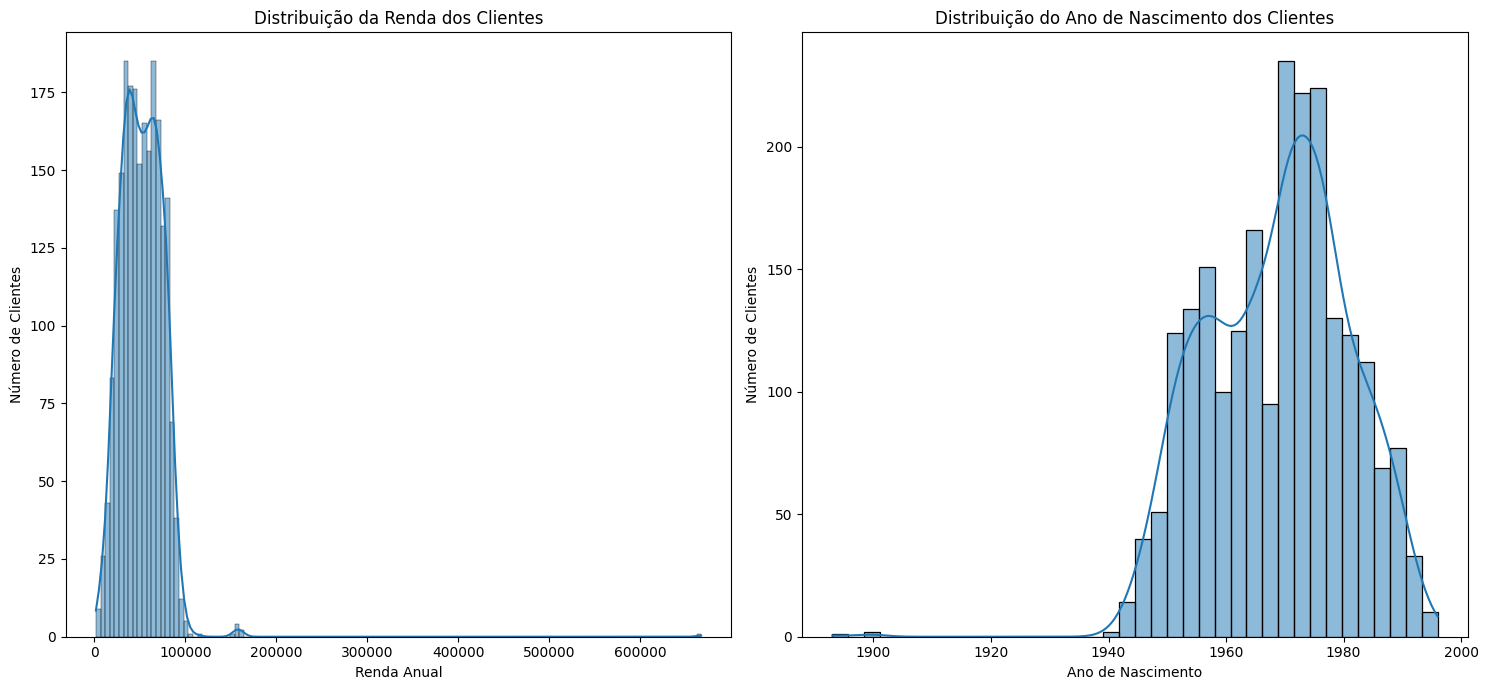

In [ ]:
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1) # Renda
sns.histplot(df['Income'].dropna(), kde=True)
plt.title('Distribuição da Renda dos Clientes')
plt.xlabel('Renda Anual')
plt.ylabel('Número de Clientes')

plt.subplot(1, 2, 2) # Ano de Nascimento
sns.histplot(df['Year_Birth'], kde=True)
plt.title('Distribuição do Ano de Nascimento dos Clientes')
plt.xlabel('Ano de Nascimento')
plt.ylabel('Número de Clientes')

plt.tight_layout()
plt.show()

### Perfil Familiar (Crianças e Adolescentes)

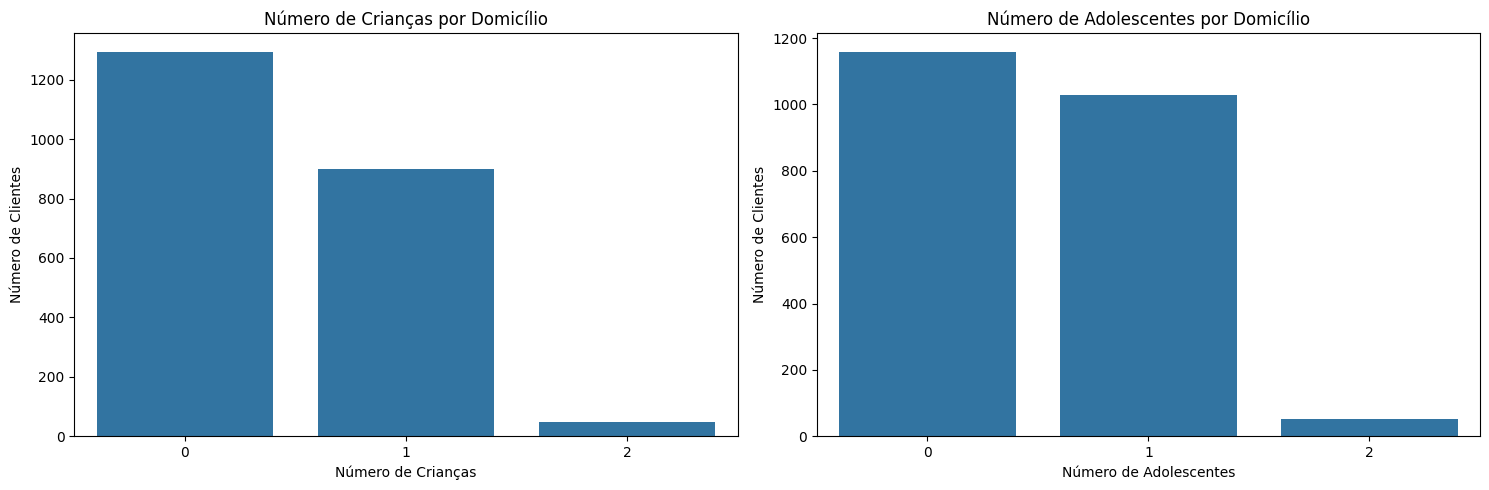

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1) # Kidhome
sns.countplot(x='Kidhome', data=df)
plt.title('Número de Crianças por Domicílio')
plt.xlabel('Número de Crianças')
plt.ylabel('Número de Clientes')

plt.subplot(1, 2, 2) # Teenhome
sns.countplot(x='Teenhome', data=df)
plt.title('Número de Adolescentes por Domicílio')
plt.xlabel('Número de Adolescentes')
plt.ylabel('Número de Clientes')

plt.tight_layout()
plt.show()

### 6. Comportamento de Consumo

Vamos analisar os gastos dos clientes em diferentes categorias de produtos para identificar suas preferências de consumo.

### Distribuição dos Gastos por Categoria de Produto

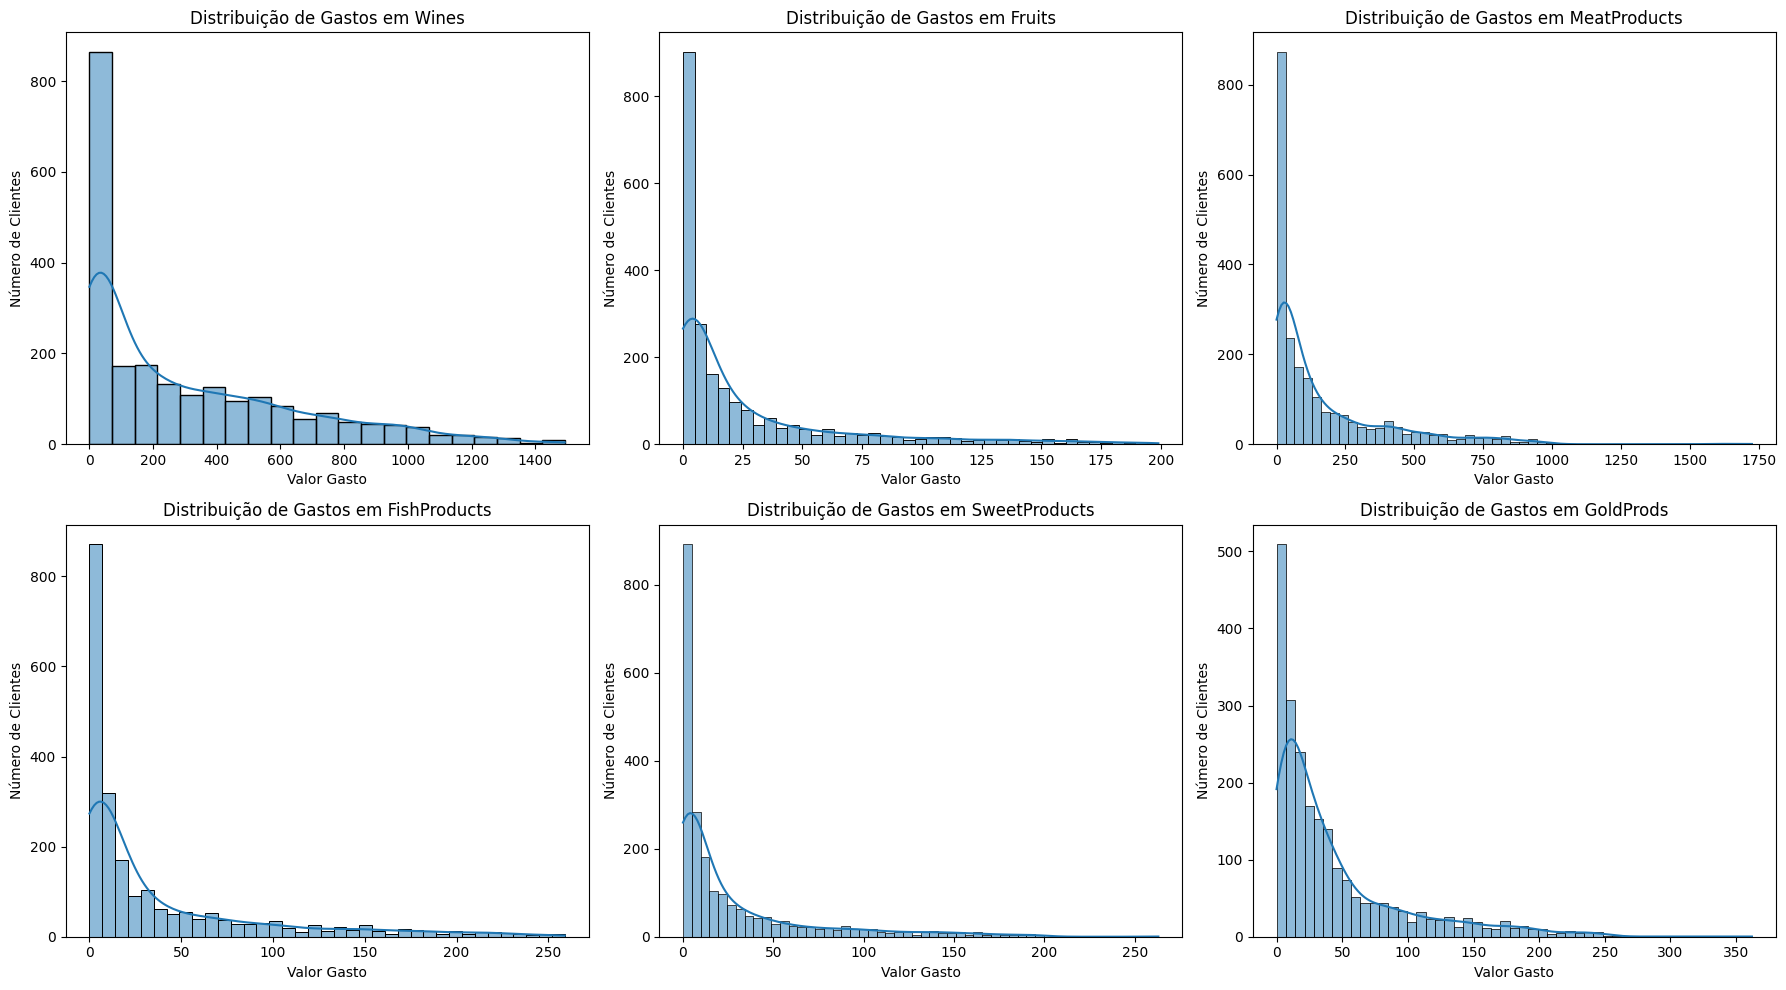

In [ ]:
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

plt.figure(figsize=(18, 10))
for i, col in enumerate(spending_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribuição de Gastos em {col.replace('Mnt', '')}')
    plt.xlabel('Valor Gasto')
    plt.ylabel('Número de Clientes')
plt.tight_layout()
plt.show()

### 7. Canais e Comportamento de Compra

Vamos investigar como os clientes interagem com os diferentes canais de compra e se há padrões distintos de comportamento.

### Distribuição das Compras por Canal

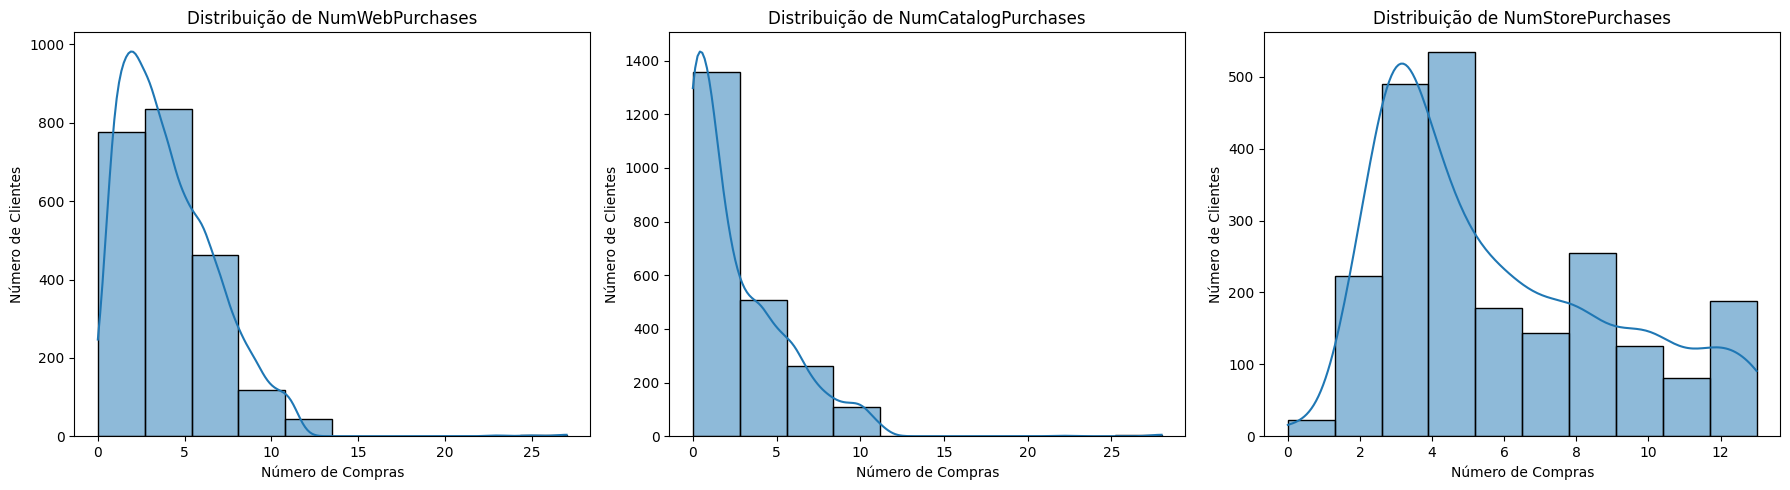

In [ ]:
purchase_channel_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']

plt.figure(figsize=(18, 5))
for i, col in enumerate(purchase_channel_cols):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=df[col].nunique() if df[col].nunique() < 10 else 10)
    plt.title(f'Distribuição de {col}')
    plt.xlabel('Número de Compras')
    plt.ylabel('Número de Clientes')
plt.tight_layout()
plt.show()

### 9. Correlação entre Variáveis Numéricas

A análise de correlação nos ajuda a entender a relação linear entre pares de variáveis numéricas. Isso é importante para identificar se variáveis se movem na mesma direção (correlação positiva), em direções opostas (correlação negativa) ou se não há relação linear aparente (próximo de zero). Para evitar um heatmap muito poluído, vamos selecionar um conjunto representativo de variáveis.

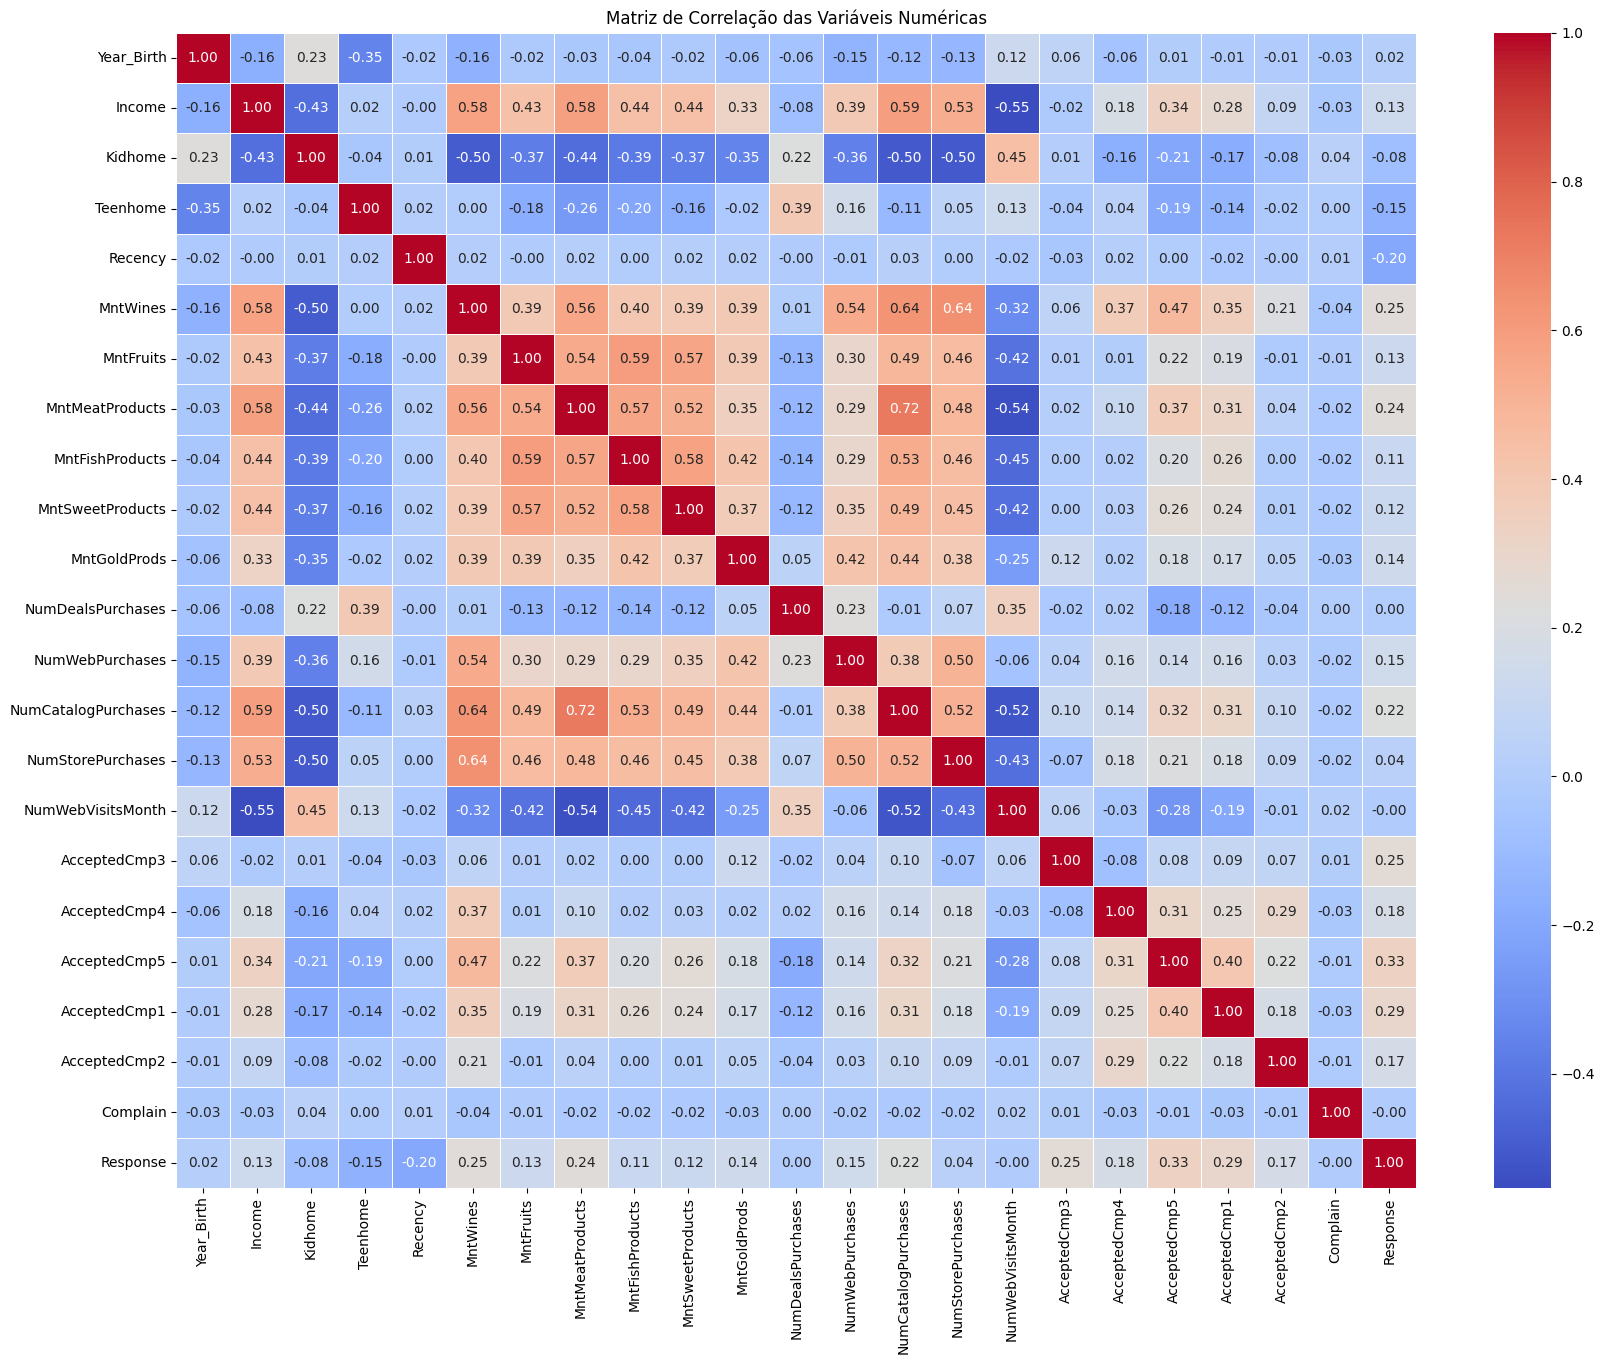

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Excluir colunas de ID e 'Z_CostContact', 'Z_Revenue' que não agregam valor à correlação para clusterização
exclude_cols = ['ID', 'Z_CostContact', 'Z_Revenue']
numerical_cols = [col for col in numerical_cols if col not in exclude_cols]

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

## Preparação de Dados I (Limpeza dos Dados)

### Criando uma Cópia do DataFrame Original

In [ ]:
# Criando uma cópia do DataFrame original para evitar modificações no df inicial
df2 = df.copy()
print(f"Cópia do DataFrame df2 criada com {df2.shape[0]} linhas e {df2.shape[1]} colunas.")

Cópia do DataFrame df2 criada com 2240 linhas e 29 colunas.


### Tratamento de Valores Ausentes em 'Income'

In [ ]:
# Comparando média e mediana de Income
income_mean = df2['Income'].mean()
income_median = df2['Income'].median()

print(f"Média da renda: {income_mean:.2f}")
print(f"Mediana da renda: {income_median:.2f}")

# Preenchendo valores ausentes com a mediana
df2['Income'].fillna(income_median, inplace=True)

print(f"Número de valores ausentes em 'Income' após o preenchimento: {df2['Income'].isnull().sum()}")

Média da renda: 52247.25
Mediana da renda: 51381.50
Número de valores ausentes em 'Income' após o preenchimento: 0


/tmp/ipykernel_384/1292266811.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['Income'].fillna(income_median, inplace=True)


### Investigação e Tratamento de Inconsistências em 'Year_Birth'

In [ ]:
# Identificando registros com 'Year_Birth' inferior a 1920
inconsistent_birth_years = df2[df2['Year_Birth'] < 1920]
print(f"Registros com 'Year_Birth' inferior a 1920: {len(inconsistent_birth_years)}")

# Removendo os registros inconsistentes
df2 = df2[df2['Year_Birth'] >= 1920]
print(f"Dimensão do df2 após remoção de anos de nascimento inconsistentes: {df2.shape[0]} linhas e {df2.shape[1]} colunas.")

Registros com 'Year_Birth' inferior a 1920: 3
Dimensão do df2 após remoção de anos de nascimento inconsistentes: 2237 linhas e 29 colunas.


### Análise de Outliers em 'Income'

Estatísticas descritivas para 'Income':
 count      2237.000000
mean      52227.407689
std       25043.266830
min        1730.000000
25%       35523.000000
50%       51381.500000
75%       68281.000000
max      666666.000000
Name: Income, dtype: float64


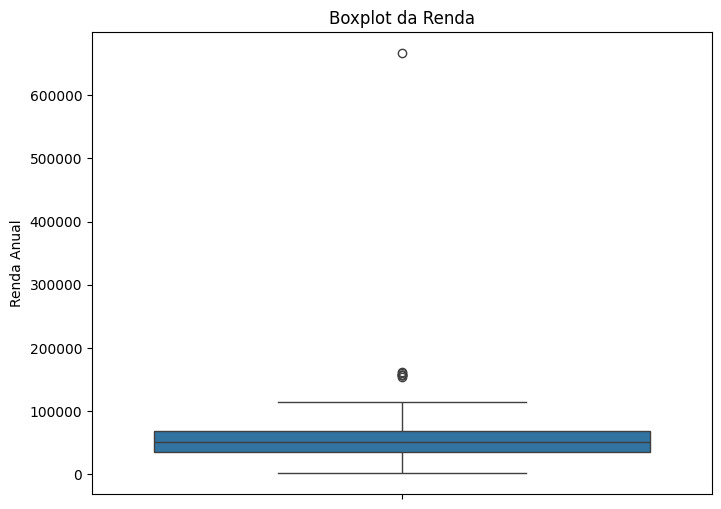

Q1 (25º percentil): 35523.00
Q3 (75º percentil): 68281.00
IQR: 32758.00
Limite superior para outliers (IQR): 117418.00
Limite inferior para outliers (IQR): -13614.00
Número de outliers identificados pelo IQR: 8


In [ ]:
# Estatísticas descritivas para Income
print("Estatísticas descritivas para 'Income':\n", df2['Income'].describe())

# Boxplot para visualizar outliers em Income
plt.figure(figsize=(8, 6))
sns.boxplot(y=df2['Income'])
plt.title('Boxplot da Renda')
plt.ylabel('Renda Anual')
plt.show()

# Calculando IQR para Income
Q1 = df2['Income'].quantile(0.25)
Q3 = df2['Income'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

print(f"Q1 (25º percentil): {Q1:.2f}")
print(f"Q3 (75º percentil): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Limite superior para outliers (IQR): {upper_bound:.2f}")
print(f"Limite inferior para outliers (IQR): {lower_bound:.2f}")

# Identificando outliers usando IQR
outliers_iqr = df2[(df2['Income'] < lower_bound) | (df2['Income'] > upper_bound)]
print(f"Número de outliers identificados pelo IQR: {len(outliers_iqr)}")

#### Registros Identificados como Outliers de 'Income' (IQR)

In [ ]:
display(outliers_iqr)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
164,8475,1973,PhD,Married,157243.0,0,1,01-03-2014,98,20,...,0,0,0,0,0,0,0,3,11,0
617,1503,1976,PhD,Together,162397.0,1,1,03-06-2013,31,85,...,1,0,0,0,0,0,0,3,11,0
655,5555,1975,Graduation,Divorced,153924.0,0,0,07-02-2014,81,1,...,0,0,0,0,0,0,0,3,11,0
687,1501,1982,PhD,Married,160803.0,0,0,04-08-2012,21,55,...,0,0,0,0,0,0,0,3,11,0
1300,5336,1971,Master,Together,157733.0,1,0,04-06-2013,37,39,...,1,0,0,0,0,0,0,3,11,0
1653,4931,1977,Graduation,Together,157146.0,0,0,29-04-2013,13,1,...,1,0,0,0,0,0,0,3,11,0
2132,11181,1949,PhD,Married,156924.0,0,0,29-08-2013,85,2,...,0,0,0,0,0,0,0,3,11,0
2233,9432,1977,Graduation,Together,666666.0,1,0,02-06-2013,23,9,...,6,0,0,0,0,0,0,3,11,0


### Remoção de Outliers Específicos em 'Income'

In [ ]:
# Removendo apenas os registros onde 'Income' é maior que 200000
initial_rows = df2.shape[0]
df2 = df2[df2['Income'] <= 200000]
removed_rows = initial_rows - df2.shape[0]
print(f"Número de registros removidos com Income > 200000: {removed_rows}")

Número de registros removidos com Income > 200000: 1


### Dimensão Final do DataFrame Após a Limpeza

In [ ]:
print(f"Dimensão final do df2: {df2.shape[0]} linhas e {df2.shape[1]} colunas.")

Dimensão final do df2: 2236 linhas e 29 colunas.


## Engenharia de Atributos

### Criação da Variável 'Age'

Estatísticas Descritivas para 'Age':
count    2236.000000
mean       45.101968
std        11.703281
min        18.000000
25%        37.000000
50%        44.000000
75%        55.000000
max        74.000000
Name: Age, dtype: float64


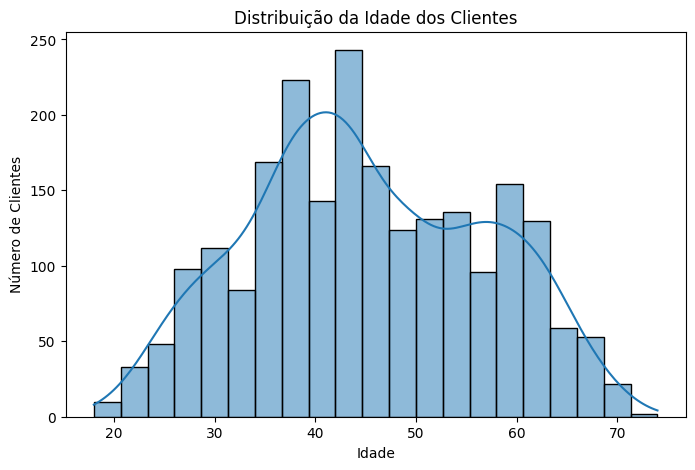

In [ ]:
# Criando a variável Age (idade do cliente)
df2['Age'] = 2014 - df2['Year_Birth']

print("Estatísticas Descritivas para 'Age':")
print(df2['Age'].describe())

plt.figure(figsize=(8, 5))
sns.histplot(df2['Age'], kde=True)
plt.title('Distribuição da Idade dos Clientes')
plt.xlabel('Idade')
plt.ylabel('Número de Clientes')
plt.show()

### Criação da Variável 'Children'

Estatísticas Descritivas para 'Children':
count    2236.000000
mean        0.950805
std         0.752204
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         3.000000
Name: Children, dtype: float64


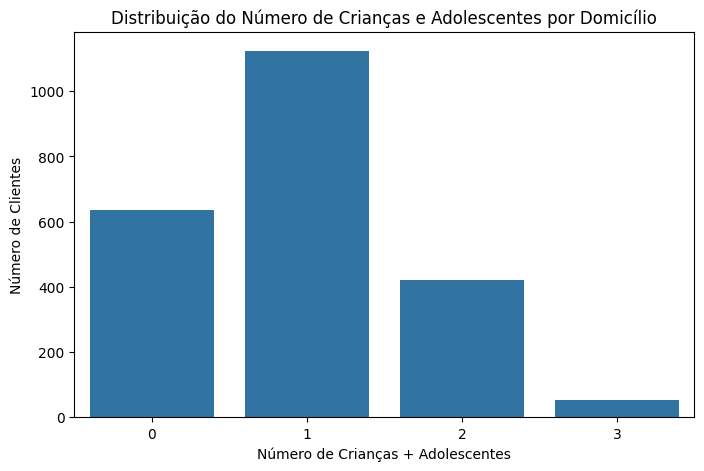

In [ ]:
# Criando a variável Children (total de crianças e adolescentes)
df2['Children'] = df2['Kidhome'] + df2['Teenhome']

print("Estatísticas Descritivas para 'Children':")
print(df2['Children'].describe())

plt.figure(figsize=(8, 5))
sns.countplot(x='Children', data=df2)
plt.title('Distribuição do Número de Crianças e Adolescentes por Domicílio')
plt.xlabel('Número de Crianças + Adolescentes')
plt.ylabel('Número de Clientes')
plt.show()

### Criação da Variável 'Total_Spent'

Estatísticas Descritivas para 'Total_Spent':
count    2236.000000
mean      605.986583
std       601.865156
min         5.000000
25%        69.000000
50%       396.500000
75%      1045.500000
max      2525.000000
Name: Total_Spent, dtype: float64


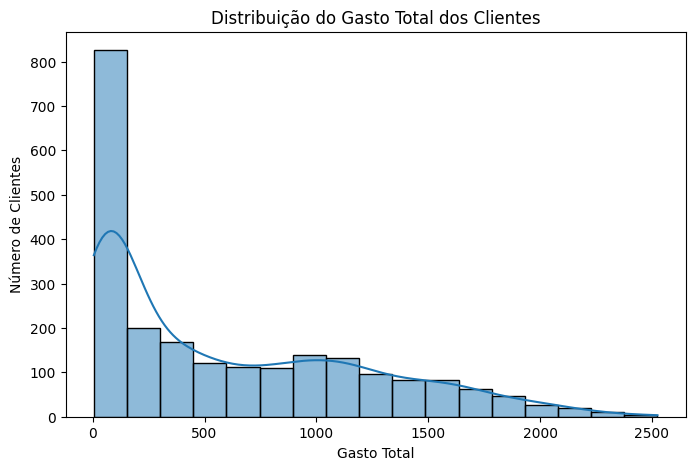

In [ ]:
# Criando a variável Total_Spent (gasto total do cliente)
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df2['Total_Spent'] = df2[spending_cols].sum(axis=1)

print("Estatísticas Descritivas para 'Total_Spent':")
print(df2['Total_Spent'].describe())

plt.figure(figsize=(8, 5))
sns.histplot(df2['Total_Spent'], kde=True)
plt.title('Distribuição do Gasto Total dos Clientes')
plt.xlabel('Gasto Total')
plt.ylabel('Número de Clientes')
plt.show()

### Criação da Variável 'Total_Purchases'

Estatísticas Descritivas para 'Total_Purchases':
count    2236.000000
mean       12.546512
std         7.206577
min         0.000000
25%         6.000000
50%        12.000000
75%        18.000000
max        32.000000
Name: Total_Purchases, dtype: float64


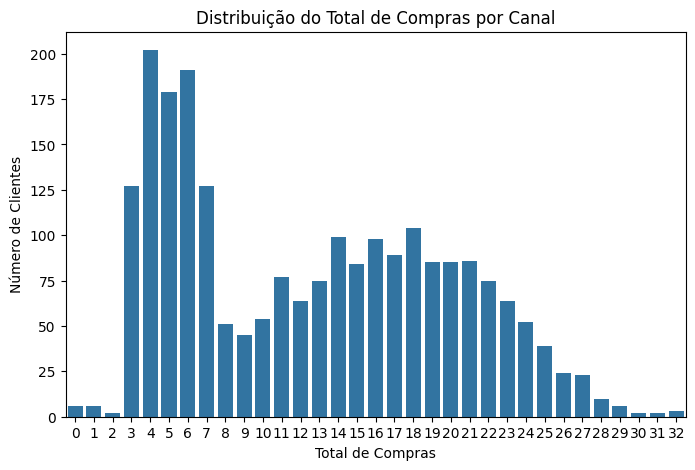

In [ ]:
# Criando a variável Total_Purchases (total de compras por canal, excluindo descontos)
purchase_channel_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df2['Total_Purchases'] = df2[purchase_channel_cols].sum(axis=1)

print("Estatísticas Descritivas para 'Total_Purchases':")
print(df2['Total_Purchases'].describe())

plt.figure(figsize=(8, 5))
sns.countplot(x='Total_Purchases', data=df2)
plt.title('Distribuição do Total de Compras por Canal')
plt.xlabel('Total de Compras')
plt.ylabel('Número de Clientes')
plt.show()

### Criação da Variável 'Customer_Tenure_Days'

Estatísticas Descritivas para 'Customer_Tenure_Days':
count    2236.000000
mean      353.773256
std       202.181561
min         0.000000
25%       180.750000
50%       356.000000
75%       529.000000
max       699.000000
Name: Customer_Tenure_Days, dtype: float64


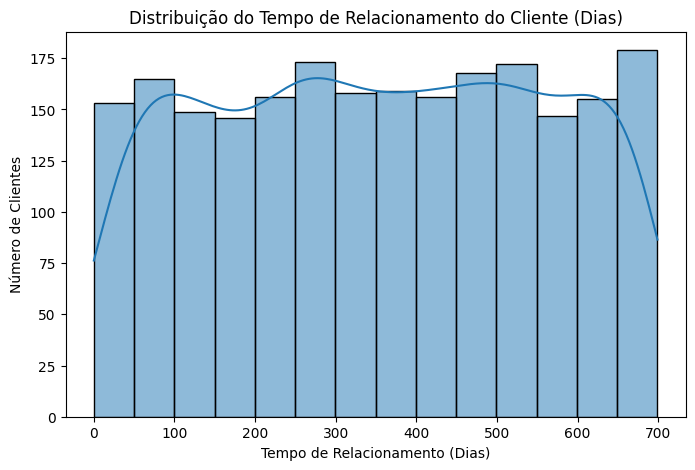

In [ ]:
# Convertendo Dt_Customer para datetime
df2['Dt_Customer'] = pd.to_datetime(df2['Dt_Customer'], format='%d-%m-%Y')

# Encontrando a maior data de cadastro no dataset
max_dt_customer = df2['Dt_Customer'].max()

# Calculando Customer_Tenure_Days (tempo de relacionamento em dias)
df2['Customer_Tenure_Days'] = (max_dt_customer - df2['Dt_Customer']).dt.days

print("Estatísticas Descritivas para 'Customer_Tenure_Days':")
print(df2['Customer_Tenure_Days'].describe())

plt.figure(figsize=(8, 5))
sns.histplot(df2['Customer_Tenure_Days'], kde=True)
plt.title('Distribuição do Tempo de Relacionamento do Cliente (Dias)')
plt.xlabel('Tempo de Relacionamento (Dias)')
plt.ylabel('Número de Clientes')
plt.show()

## Preparação de Dados II (Tranformação dos dados)

### Seleção das Features para Clusterização

In [ ]:
# Lista das features selecionadas para a clusterização
cluster_features = ['Income', 'Age', 'Children', 'Recency', 'Total_Spent', 'Total_Purchases', 'NumDealsPurchases', 'NumWebVisitsMonth', 'Customer_Tenure_Days']

# Criando o DataFrame X_cluster com as features selecionadas
X_cluster = df2[cluster_features].copy()

print("Features selecionadas para clusterização:\n", cluster_features)

Features selecionadas para clusterização:
 ['Income', 'Age', 'Children', 'Recency', 'Total_Spent', 'Total_Purchases', 'NumDealsPurchases', 'NumWebVisitsMonth', 'Customer_Tenure_Days']


### Verificação de Dimensão, Tipos de Dados e Valores Ausentes de `X_cluster`

In [ ]:
print(f"Dimensão de X_cluster: {X_cluster.shape[0]} linhas e {X_cluster.shape[1]} colunas.")
print("\nTipos de dados em X_cluster:")
print(X_cluster.info())
print("\nValores ausentes em X_cluster:")
print(X_cluster.isnull().sum())

Dimensão de X_cluster: 2236 linhas e 9 colunas.

Tipos de dados em X_cluster:
<class 'pandas.core.frame.DataFrame'>
Index: 2236 entries, 0 to 2239
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2236 non-null   float64
 1   Age                   2236 non-null   int64  
 2   Children              2236 non-null   int64  
 3   Recency               2236 non-null   int64  
 4   Total_Spent           2236 non-null   int64  
 5   Total_Purchases       2236 non-null   int64  
 6   NumDealsPurchases     2236 non-null   int64  
 7   NumWebVisitsMonth     2236 non-null   int64  
 8   Customer_Tenure_Days  2236 non-null   int64  
dtypes: float64(1), int64(8)
memory usage: 174.7 KB
None

Valores ausentes em X_cluster:
Income                  0
Age                     0
Children                0
Recency                 0
Total_Spent             0
Total_Purchases         0
NumDealsPurchas

### Aplicação do `StandardScaler`

In [ ]:
# Instanciando o StandardScaler
scaler = StandardScaler()

# Aplicando o scaler aos dados
X_scaled = scaler.fit_transform(X_cluster)

# Convertendo o array padronizado de volta para DataFrame, mantendo os nomes das colunas
X_scaled = pd.DataFrame(X_scaled, columns=cluster_features)

print("DataFrame X_scaled criado e padronizado.")

DataFrame X_scaled criado e padronizado.


### Verificação das Médias e Desvios Padrão Após Padronização

In [ ]:
print("Médias das features em X_scaled (devem ser próximas de 0):\n", X_scaled.mean())
print("\nDesvios padrão das features em X_scaled (devem ser próximas de 1):\n", X_scaled.std())

Médias das features em X_scaled (devem ser próximas de 0):
 Income                 -7.785464e-17
Age                     6.514368e-17
Children                7.944351e-17
Recency                -7.149916e-17
Total_Spent             4.766610e-18
Total_Purchases         8.738786e-18
NumDealsPurchases       1.271096e-17
NumWebVisitsMonth      -1.525315e-16
Customer_Tenure_Days    2.542192e-17
dtype: float64

Desvios padrão das features em X_scaled (devem ser próximas de 1):
 Income                  1.000224
Age                     1.000224
Children                1.000224
Recency                 1.000224
Total_Spent             1.000224
Total_Purchases         1.000224
NumDealsPurchases       1.000224
NumWebVisitsMonth       1.000224
Customer_Tenure_Days    1.000224
dtype: float64


##Modelagem

###K-Means

In [ ]:
kmeans =  KMeans(n_clusters=3, n_init=10 ,random_state=42)

kmeans.fit(X_scaled)



KMeans(n_clusters=3, n_init=10, random_state=42)

In [ ]:
kmeans_labels = kmeans.labels_

kmeans_labels

array([1, 0, 1, ..., 1, 1, 2], dtype=int32)

In [ ]:
kmeans_labels[:10]

array([1, 0, 1, 0, 2, 1, 2, 0, 0, 0], dtype=int32)

In [ ]:
unique_labels, counts = np.unique(kmeans_labels, return_counts=True)

for label, count in zip(unique_labels, counts):
    print(f"Cluster {label}: {count} clientes")

Cluster 0: 1009 clientes
Cluster 1: 737 clientes
Cluster 2: 490 clientes


### DBSCAN

In [ ]:
dbscan = DBSCAN(eps=0.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_scaled)

In [ ]:
dbscan_labels[:10]

unique_labels, counts = np.unique(dbscan_labels, return_counts=True)

for label, count in zip(unique_labels, counts):
    if label == -1:
        print(f"Ruído {label}: {count} clientes (outliers)")
    else:
        print(f"Cluster {label}: {count} clientes")



Ruído -1: 2229 clientes (outliers)
Cluster 0: 7 clientes


### Clusterização Hierárquica

In [ ]:
hierarchial = AgglomerativeClustering(n_clusters=3)

hierarchial_labels = hierarchial.fit_predict(X_scaled)

In [ ]:
hierarchial_labels[:10]

array([0, 1, 2, 1, 0, 0, 0, 1, 1, 1])

In [ ]:
unique_labels, counts = np.unique(hierarchial_labels, return_counts=True)

for label, count in zip(unique_labels, counts):
    print(f"Cluster {label}: {count} clientes")

Cluster 0: 729 clientes
Cluster 1: 1011 clientes
Cluster 2: 496 clientes


## Avaliação de Clusterização

K-means

In [ ]:
silhouette_kmeans = silhouette_score(X_scaled, kmeans_labels)
db_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)


print(f"Silhouette Score (K-Means): {silhouette_kmeans:.3f}")
print(f"Davies-Bouldin Index (K-Means): {db_kmeans:.3f}")

Silhouette Score (K-Means): 0.232
Davies-Bouldin Index (K-Means): 1.613


DBSCAN

In [ ]:
non_noise_mask = (dbscan_labels != -1)
X_scaled_non_noise = X_scaled[non_noise_mask]

dbscan_labels_non_noise = dbscan_labels[non_noise_mask]

num_dbscan_clusters = len(np.unique(dbscan_labels_non_noise)) if (len(np.unique(dbscan_labels_non_noise)) > 0) else 0

percent_noise = (len(dbscan_labels) - len(dbscan_labels_non_noise)) / len(dbscan_labels) * 100

print(f"Número de clusters identificados por DBSCAN: {num_dbscan_clusters}")
print(f"Percentual de ruído identificado por DBSCAN: {percent_noise:.2f}%")


Número de clusters identificados por DBSCAN: 1
Percentual de ruído identificado por DBSCAN: 99.69%


Clusterização Hierarquica

In [ ]:
silhouette_hierarquial = silhouette_score(X_scaled, hierarchial_labels)
db_hierarquial = davies_bouldin_score(X_scaled, hierarchial_labels)


print(f"Silhouette Score (K-Means): {silhouette_hierarquial:.3f}")
print(f"Davies-Bouldin Index (K-Means): {db_hierarquial:.3f}")

Silhouette Score (K-Means): 0.200
Davies-Bouldin Index (K-Means): 1.762


In [ ]:
print(f"Silhouette Score (K-Means): {silhouette_kmeans:.3f}")
print(f"Silhouette Score (Hierárquica): {silhouette_hierarquial:.3f}")
print('-----------------------------------------------------------------')
print(f"Davies-Bouldin Index (K-Means): {db_kmeans:.3f}")
print(f"Davies-Bouldin Index (Hierárquica): {db_hierarquial:.3f}")

Silhouette Score (K-Means): 0.232
Silhouette Score (Hierárquica): 0.200
-----------------------------------------------------------------
Davies-Bouldin Index (K-Means): 1.613
Davies-Bouldin Index (Hierárquica): 1.762


In [ ]:
X_scaled

,Income,Age,Children,Recency,Total_Spent,Total_Purchases,NumDealsPurchases,NumWebVisitsMonth,Customer_Tenure_Days
0,0.288947,1.016868,-1.264308,0.306856,1.680176,1.312080,0.348738,0.692865,1.529793
1,-0.262003,1.273264,1.395139,-0.383971,-0.962202,-1.186198,-0.168700,-0.131421,-1.191143
2,0.918423,0.333146,-1.264308,-0.798467,0.282541,1.034493,-0.686137,-0.543564,-0.206659
3,-1.182183,-1.290693,0.065416,-0.798467,-0.918994,-0.908611,-0.168700,0.280722,-1.062517
4,0.296187,-1.034298,0.065416,1.550344,-0.305762,0.201734,1.383614,-0.131421,-0.953679
...,...,...,...,...,...,...,...,...,...
2231,0.433060,0.162216,0.065416,-0.107640,1.221499,0.479321,-0.168700,-0.131421,0.134695
2232,0.563440,1.956986,2.724862,0.237773,-0.269201,0.340527,2.418490,0.692865,-1.656175
2233,0.234898,-1.034298,-1.264308,1.446720,1.055312,0.756907,-0.686137,0.280722,-0.983362
2234,0.807803,1.102333,0.065416,-1.420212,0.393886,1.173287,-0.168700,-0.955707,-0.978415


Vizualização com PCA

In [ ]:
def plot_pca(labels, df):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(df)

    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=X_pca[:, 0],
        y=X_pca[:, 1],
        hue=labels,
        palette='viridis',
        legend='full',
        alpha=0.8
    )

    plt.title('Visualização de Clusters com PCA')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.show()

PCA K-Means

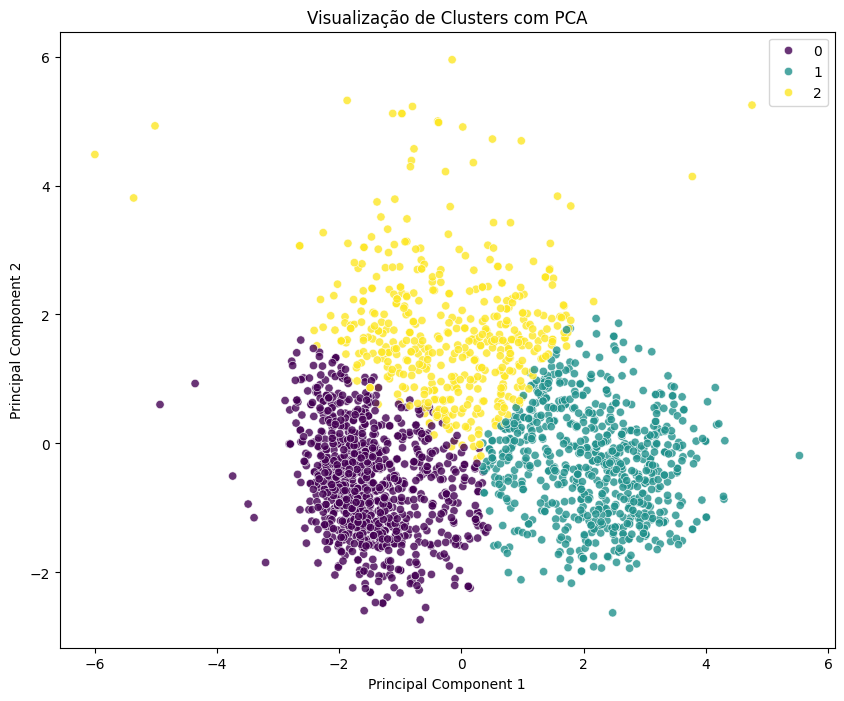

In [ ]:
plot_pca(kmeans_labels, X_scaled)

PCA Clusterização Hierárquica

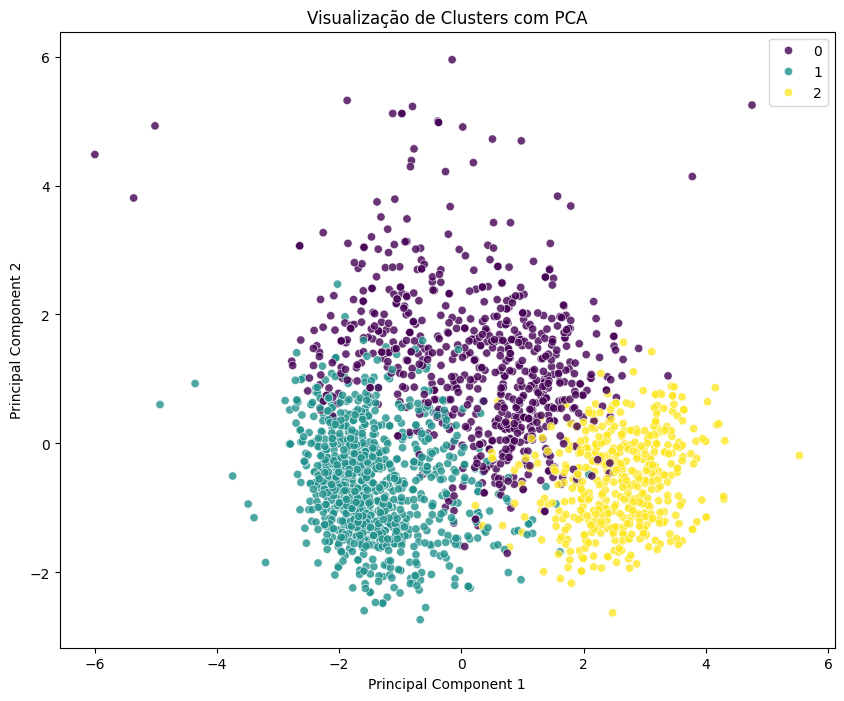

In [ ]:
plot_pca(hierarchial_labels, X_scaled)

# Otimização dos Modelos de Clusterização

## 1. Otimização K-Means

Otimizaremos os parâmetros `init` e `n_init` para o algoritmo K-Means, mantendo `n_clusters = 3` conforme a restrição de negócio. Avaliaremos cada combinação utilizando o Silhouette Score (maior é melhor) e o Davies-Bouldin Index (menor é melhor).

In [ ]:
# Definindo os parâmetros para otimização
init_strategies = ["k-means++", "random"]
n_init_values = [10, 20, 30, 50]

kmeans_tuning_results = []

for init in init_strategies:
    for n_init in n_init_values:
        kmeans = KMeans(n_clusters=3, init=init, n_init=n_init, random_state=42, algorithm='lloyd')
        kmeans.fit(X_scaled)
        labels = kmeans.labels_

        silhouette = silhouette_score(X_scaled, labels)
        davies_bouldin = davies_bouldin_score(X_scaled, labels)

        kmeans_tuning_results.append({
            'init': init,
            'n_init': n_init,
            'Silhouette_Score': silhouette,
            'Davies_Bouldin_Index': davies_bouldin
        })

kmeans_tuning_results = pd.DataFrame(kmeans_tuning_results)
print("Resultados da otimização K-Means:")
display(kmeans_tuning_results)

Resultados da otimização K-Means:


,init,n_init,Silhouette_Score,Davies_Bouldin_Index
0,k-means++,10,0.232371,1.612986
1,k-means++,20,0.232371,1.612986
2,k-means++,30,0.232371,1.612986
3,k-means++,50,0.232371,1.612986
4,random,10,0.232371,1.612986
5,random,20,0.232371,1.612986
6,random,30,0.232371,1.612986
7,random,50,0.232371,1.612986


Selecionamos a melhor configuração de hiperparâmetros para o K-Means com base no maior Silhouette Score e menor Davies-Bouldin Index.

In [ ]:
# Selecionando a melhor configuração para K-Means
best_kmeans_config = kmeans_tuning_results.sort_values(by=['Silhouette_Score', 'Davies_Bouldin_Index'], ascending=[False, True]).iloc[0]

print("Melhor configuração K-Means:")
print(best_kmeans_config)

# Treinando o modelo final com a melhor configuração
kmeans_final = KMeans(n_clusters=3, init=best_kmeans_config['init'], n_init=int(best_kmeans_config['n_init']), random_state=42, algorithm='lloyd')
kmeans_final.fit(X_scaled)
kmeans_final_labels = kmeans_final.labels_

print("\nK-Means final treinado e labels gerados.")

Melhor configuração K-Means:
init                    k-means++
n_init                         10
Silhouette_Score         0.232371
Davies_Bouldin_Index     1.612986
Name: 0, dtype: object

K-Means final treinado e labels gerados.


## 2. Otimização Clusterização Hierárquica

Para a Clusterização Hierárquica, otimizaremos os parâmetros `linkage` e `metric`, mantendo `n_clusters = 3`. A métrica 'euclidean' será usada obrigatoriamente com o `linkage='ward'`, enquanto outras métricas serão testadas com os demais tipos de `linkage`. O objetivo é maximizar o Silhouette Score e minimizar o Davies-Bouldin Index.

In [ ]:
# Definindo os parâmetros para otimização da Clusterização Hierárquica
linkage_methods = ["ward", "complete", "average", "single"]
metric_options = {
    "ward": ["euclidean"],
    "complete": ["euclidean", "manhattan", "cosine"],
    "average": ["euclidean", "manhattan", "cosine"],
    "single": ["euclidean", "manhattan", "cosine"]
}

hierarchical_tuning_results = []

for linkage in linkage_methods:
    for metric in metric_options[linkage]:
        # Ward aceita apenas 'euclidean' como métrica, outros linkages podem aceitar outras
        if linkage == 'ward' and metric != 'euclidean':
            continue

        try:
            hierarchical = AgglomerativeClustering(n_clusters=3, linkage=linkage, metric=metric)
            labels = hierarchical.fit_predict(X_scaled)

            silhouette = silhouette_score(X_scaled, labels)
            davies_bouldin = davies_bouldin_score(X_scaled, labels)

            hierarchical_tuning_results.append({
                'linkage': linkage,
                'metric': metric,
                'Silhouette_Score': silhouette,
                'Davies_Bouldin_Index': davies_bouldin
            })
        except Exception as e:
            print(f"Erro ao testar linkage={linkage}, metric={metric}: {e}")

hierarchical_tuning_results = pd.DataFrame(hierarchical_tuning_results)
print("Resultados da otimização Clusterização Hierárquica:")
display(hierarchical_tuning_results)

Resultados da otimização Clusterização Hierárquica:


,linkage,metric,Silhouette_Score,Davies_Bouldin_Index
0,ward,euclidean,0.200195,1.761589
1,complete,euclidean,0.346693,1.134921
2,complete,manhattan,0.455208,1.075117
3,complete,cosine,0.131667,2.144954
4,average,euclidean,0.543298,0.763750
5,average,manhattan,0.455208,1.075117
6,average,cosine,0.201696,1.783639
7,single,euclidean,0.550604,0.555925
8,single,manhattan,0.511022,0.487304
9,single,cosine,0.142789,0.708569


Selecionamos a melhor configuração de hiperparâmetros para a Clusterização Hierárquica com base no maior Silhouette Score e menor Davies-Bouldin Index.

In [ ]:
# Selecionando a melhor configuração para Clusterização Hierárquica
best_hierarchical_config = hierarchical_tuning_results.sort_values(by=['Silhouette_Score', 'Davies_Bouldin_Index'], ascending=[False, True]).iloc[0]

print("Melhor configuração Clusterização Hierárquica:")
print(best_hierarchical_config)

# Treinando o modelo final com a melhor configuração
hierarchical_final = AgglomerativeClustering(n_clusters=3, linkage=best_hierarchical_config['linkage'], metric=best_hierarchical_config['metric'])
hierarchical_final_labels = hierarchical_final.fit_predict(X_scaled)

print("\nClusterização Hierárquica final treinada e labels gerados.")

Melhor configuração Clusterização Hierárquica:
linkage                    single
metric                  euclidean
Silhouette_Score         0.550604
Davies_Bouldin_Index     0.555925
Name: 7, dtype: object

Clusterização Hierárquica final treinada e labels gerados.


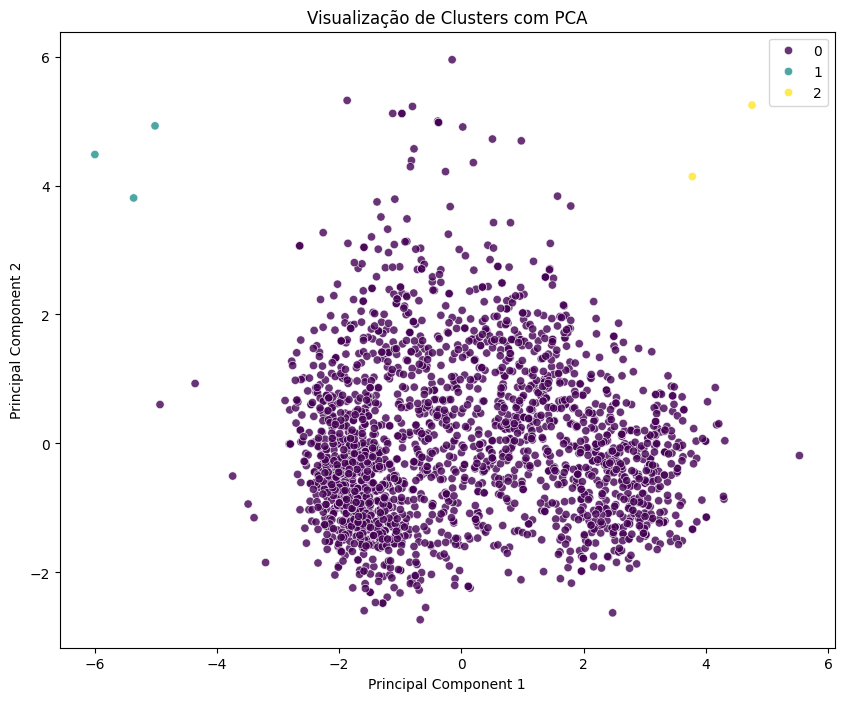

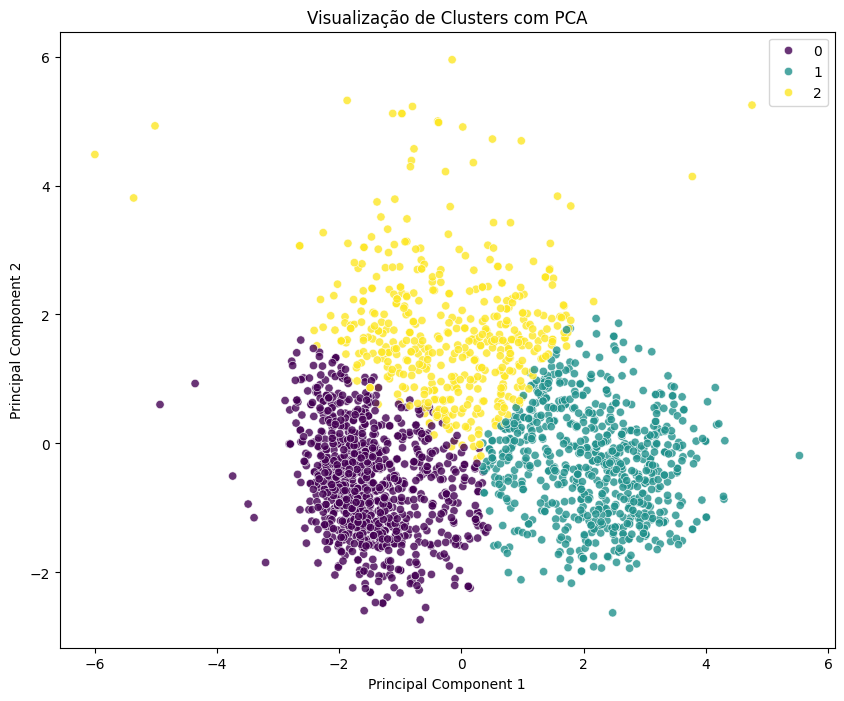

In [ ]:
plot_pca(hierarchical_final_labels, X_scaled)

plot_pca(kmeans_final_labels, X_scaled)

## 4. Comparação Final dos Modelos Otimizados

Nesta etapa, consolidamos os resultados dos modelos otimizados (K-Means e Hierárquico) em um único DataFrame para facilitar a comparação. Todos os modelos apresentados aqui representam exatamente 3 clusters, conforme o requisito de negócio.

In [ ]:
# Coletando as métricas e hiperparâmetros dos modelos otimizados

# K-Means
kmeans_best_row = kmeans_tuning_results.sort_values(by=['Silhouette_Score', 'Davies_Bouldin_Index'], ascending=[False, True]).iloc[0]
kmeans_comparison = {
    'Modelo': 'K-Means',
    'Hiperparâmetros': f"init={kmeans_best_row['init']}, n_init={int(kmeans_best_row['n_init'])}",
    'Número de Clusters': 3,
    'Silhouette_Score': kmeans_best_row['Silhouette_Score'],
    'Davies_Bouldin_Index': kmeans_best_row['Davies_Bouldin_Index']
}

# Clusterização Hierárquica
hierarchical_best_row = hierarchical_tuning_results.sort_values(by=['Silhouette_Score', 'Davies_Bouldin_Index'], ascending=[False, True]).iloc[0]
hierarchical_comparison = {
    'Modelo': 'Hierárquico',
    'Hiperparâmetros': f"linkage={hierarchical_best_row['linkage']}, metric={hierarchical_best_row['metric']}",
    'Número de Clusters': 3,
    'Silhouette_Score': hierarchical_best_row['Silhouette_Score'],
    'Davies_Bouldin_Index': hierarchical_best_row['Davies_Bouldin_Index']
}

# Criando o DataFrame de comparação
final_comparison_df = pd.DataFrame([kmeans_comparison, hierarchical_comparison])

print("Comparação dos Modelos de Clusterização Otimizados:")
display(final_comparison_df)

Comparação dos Modelos de Clusterização Otimizados:


,Modelo,Hiperparâmetros,Número de Clusters,Silhouette_Score,Davies_Bouldin_Index
0,K-Means,"init=k-means++, n_init=10",3,0.232371,1.612986
1,Hierárquico,"linkage=single, metric=euclidean",3,0.550604,0.555925


Para entender a distribuição dos clientes em cada cluster, apresentamos a quantidade de amostras por cluster para os modelos K-Means e Hierárquico finais.

In [ ]:
# Quantidade de amostras por cluster para K-Means final
unique_labels_kmeans, counts_kmeans = np.unique(kmeans_final_labels, return_counts=True)
kmeans_cluster_counts = pd.DataFrame({
    'Cluster': unique_labels_kmeans,
    'Contagem de Clientes': counts_kmeans
})
kmeans_cluster_counts['Modelo'] = 'K-Means Final'

# Quantidade de amostras por cluster para Hierárquico final
unique_labels_hierarchical, counts_hierarchical = np.unique(hierarchical_final_labels, return_counts=True)
hierarchical_cluster_counts = pd.DataFrame({
    'Cluster': unique_labels_hierarchical,
    'Contagem de Clientes': counts_hierarchical
})
hierarchical_cluster_counts['Modelo'] = 'Hierárquico Final'

# Concatenando os DataFrames e exibindo
cluster_samples_comparison_df = pd.concat([kmeans_cluster_counts, hierarchical_cluster_counts], ignore_index=True)
print("Quantidade de amostras por cluster nos modelos otimizados:")
display(cluster_samples_comparison_df)

Quantidade de amostras por cluster nos modelos otimizados:


,Cluster,Contagem de Clientes,Modelo
0,0,1009,K-Means Final
1,1,737,K-Means Final
2,2,490,K-Means Final
3,0,2231,Hierárquico Final
4,1,3,Hierárquico Final
5,2,2,Hierárquico Final


In [ ]:
best_model = kmeans_final
best_model_labels = kmeans_final_labels
best_model_name = "K-Means"

# Interpretação dos Clusters e Geração de Insights

## 1. Associar os clusters aos clientes

Primeiro, criaremos uma cópia do `df2` chamada `df_segmented` e adicionaremos uma nova coluna 'Cluster' com os rótulos (`best_model_labels`) atribuídos pelo modelo de clusterização final. Em seguida, analisaremos a distribuição da quantidade e percentual de clientes em cada cluster.

In [ ]:
# Criar uma cópia do df2 para trabalhar com os dados segmentados
df_segmented = df2.copy()

# Associar os labels do modelo final ao DataFrame
df_segmented['Cluster'] = best_model_labels

# Exibir a quantidade e o percentual de clientes por cluster
cluster_counts = df_segmented['Cluster'].value_counts().sort_index()
cluster_percentages = df_segmented['Cluster'].value_counts(normalize=True).sort_index() * 100

cluster_summary = pd.DataFrame({
    'Quantidade de Clientes': cluster_counts,
    'Percentual de Clientes (%)': cluster_percentages
})

print(f"Distribuição de clientes por cluster ({best_model_name} - Modelo Otimizado):")
display(cluster_summary)

# Se o modelo vencedor for DBSCAN e houver label -1 (ruído), identificar esses registros separadamente
# Neste caso, 'best_model_name' é K-Means, então esta parte não será executada, mas é incluída para robustez.
if best_model_name == 'DBSCAN':
    noise_count = (best_model_labels == -1).sum()
    if noise_count > 0:
        print(f"\nRegistros de ruído (label -1) identificados: {noise_count} clientes.")

Distribuição de clientes por cluster (K-Means - Modelo Otimizado):


,Quantidade de Clientes,Percentual de Clientes (%)
Cluster,,
0,1009,45.125224
1,737,32.960644
2,490,21.914132


## 2. Perfil geral dos clusters

Vamos calcular as estatísticas descritivas (média) das principais variáveis numéricas para cada cluster. Isso nos dará uma visão inicial das características gerais de cada grupo de clientes.

Perfil Geral dos Clusters (Médias):


,Age,Income,Recency,Total_Spent,Total_Purchases,Children
Cluster,,,,,,
0,42.351833,34622.496531,48.958375,99.768087,5.952428,1.201189
1,46.530529,73905.377883,49.058345,1237.603799,19.082768,0.337856
2,48.616327,54619.760204,49.528571,698.379592,16.293878,1.357143


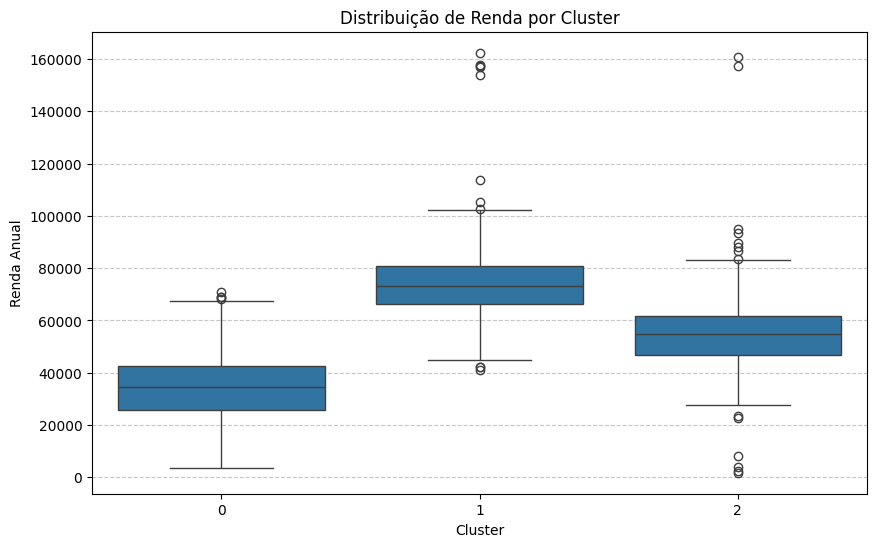

In [ ]:
general_profile_features = ['Age', 'Income', 'Recency', 'Total_Spent', 'Total_Purchases', 'Children']

# Calcular as médias das variáveis de perfil geral por cluster
cluster_general_profile = df_segmented.groupby('Cluster')[general_profile_features].mean()

print("Perfil Geral dos Clusters (Médias):")
display(cluster_general_profile)

# Visualização da distribuição de Renda por Cluster (exemplo para comparação)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='Income', data=df_segmented)
plt.title('Distribuição de Renda por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Renda Anual')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 3. Comportamento de consumo

Agora, exploraremos os padrões de gastos dos clientes em diferentes categorias de produtos para cada cluster. Isso revelará as preferências de consumo que distinguem um segmento do outro.

Comportamento de Consumo por Cluster (Médias de Gastos):


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Cluster,,,,,,
0,42.572844,5.363726,22.645193,7.594648,5.312190,16.279485
1,583.807327,57.084125,382.147897,83.139756,59.750339,71.674355
2,422.055102,23.000000,140.577551,30.600000,22.767347,59.379592


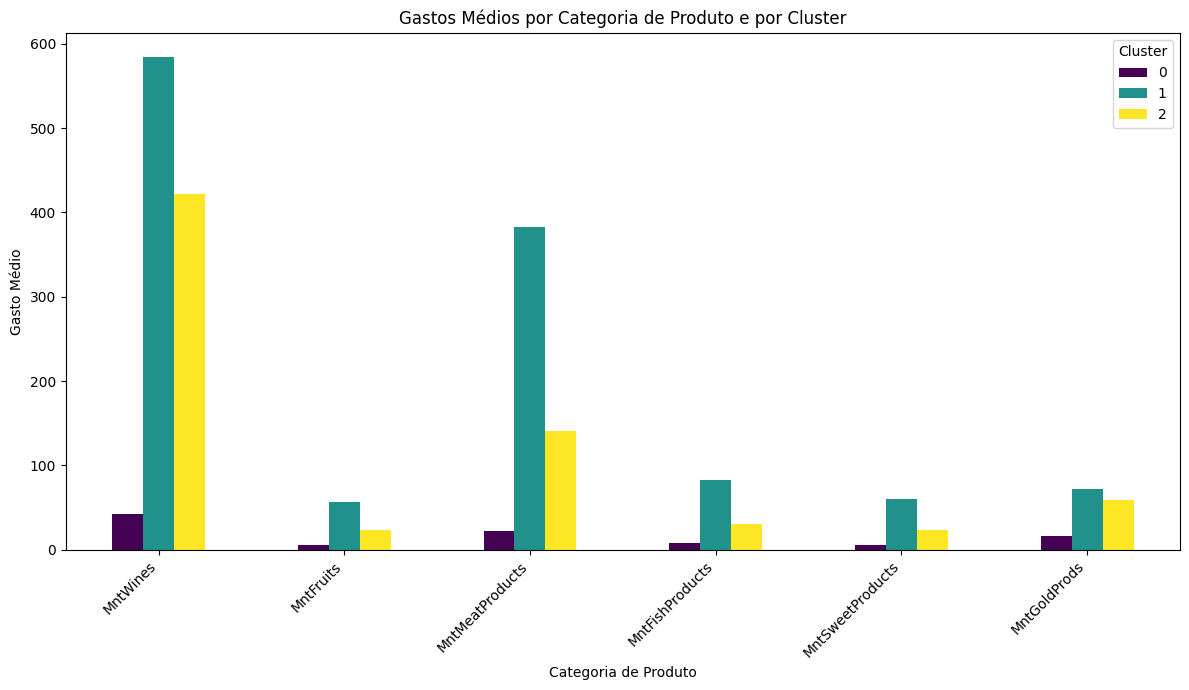

In [ ]:
consumption_features = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

# Calcular as médias das variáveis de consumo por cluster
cluster_consumption_profile = df_segmented.groupby('Cluster')[consumption_features].mean()

print("Comportamento de Consumo por Cluster (Médias de Gastos):")
display(cluster_consumption_profile)

# Visualização comparativa dos gastos por categoria para cada cluster
cluster_consumption_profile.T.plot(kind='bar', figsize=(12, 7), colormap='viridis')
plt.title('Gastos Médios por Categoria de Produto e por Cluster')
plt.xlabel('Categoria de Produto')
plt.ylabel('Gasto Médio')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

## 4. Canais e comportamento de compra

Esta seção analisará como os clientes de cada cluster utilizam os diferentes canais de compra (web, catálogo, loja) e seu envolvimento com promoções e visitas ao site. Isso nos ajudará a entender as preferências de interação de cada segmento.

Canais e Comportamento de Compra por Cluster (Médias):


,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth
Cluster,,,,,
0,2.149653,0.550050,3.252725,1.850347,6.359762
1,5.347354,5.317503,8.417910,1.295794,3.037992
2,6.183673,3.022449,7.087755,4.855102,6.606122


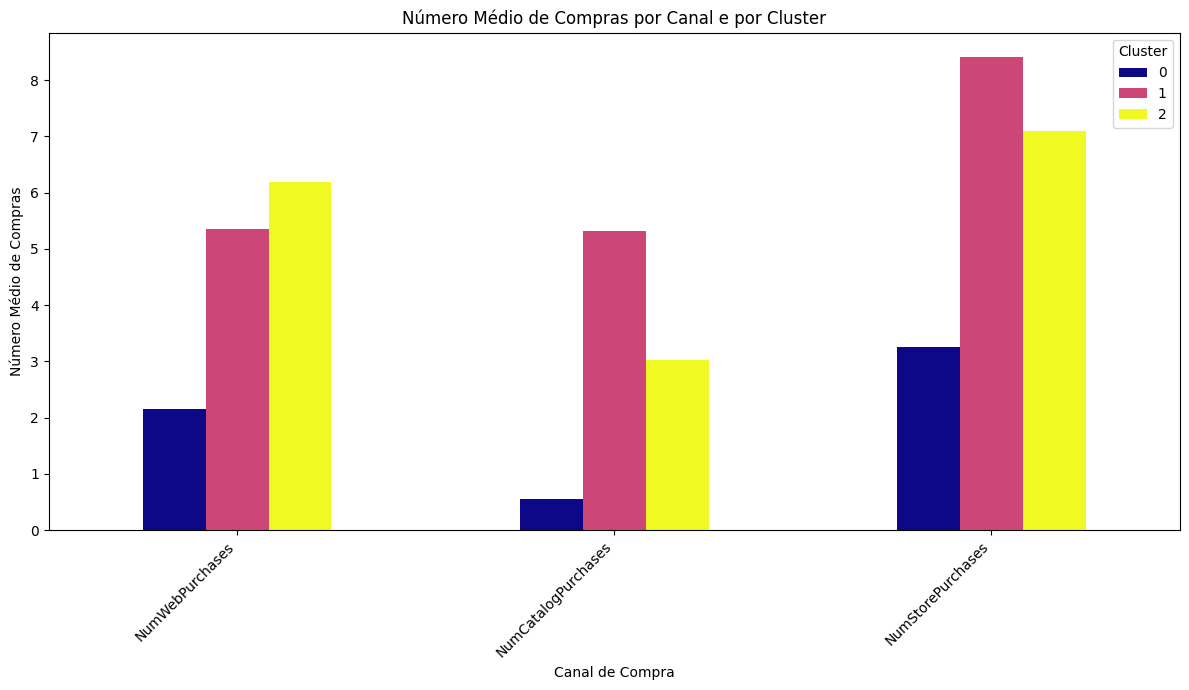

In [ ]:
channel_behavior_features = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases', 'NumWebVisitsMonth']

# Calcular as médias das variáveis de canais e comportamento de compra por cluster
cluster_channel_profile = df_segmented.groupby('Cluster')[channel_behavior_features].mean()

print("Canais e Comportamento de Compra por Cluster (Médias):")
display(cluster_channel_profile)

# Visualização comparativa dos canais de compra para cada cluster
cluster_channel_profile[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].T.plot(kind='bar', figsize=(12, 7), colormap='plasma')
plt.title('Número Médio de Compras por Canal e por Cluster')
plt.xlabel('Canal de Compra')
plt.ylabel('Número Médio de Compras')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

## 5. Variáveis externas à formação dos clusters

Para complementar a interpretação dos clusters, analisaremos variáveis que não foram usadas diretamente na formação dos clusters, como `Education`, `Marital_Status` e a aceitação de campanhas. Isso pode revelar informações contextuais importantes sobre cada segmento.

In [ ]:
external_features_cat = ['Education', 'Marital_Status']
external_features_campaign = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']

print("Distribuição de Escolaridade por Cluster:")
display(pd.crosstab(df_segmented['Cluster'], df_segmented['Education'], normalize='index') * 100)

print("\nDistribuição de Estado Civil por Cluster:")
display(pd.crosstab(df_segmented['Cluster'], df_segmented['Marital_Status'], normalize='index') * 100)

print("\nTaxa de Aceitação de Campanhas e Resposta por Cluster (Médias):")
display(df_segmented.groupby('Cluster')[external_features_campaign].mean() * 100)

Distribuição de Escolaridade por Cluster:


Education,2n Cycle,Basic,Graduation,Master,PhD
Cluster,,,,,
0,11.000991,5.252725,48.662042,16.551041,18.533201
1,7.869742,0.000000,53.052917,15.061058,24.016282
2,6.530612,0.204082,49.795918,18.775510,24.693878



Distribuição de Estado Civil por Cluster:


Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Cluster,,,,,,,,
0,0.00000,0.198216,9.217047,39.742319,23.092170,25.272547,2.477701,0.000000
1,0.27137,0.000000,10.447761,37.042062,21.981004,26.051560,4.206242,0.000000
2,0.00000,0.204082,12.448980,38.775510,17.142857,26.734694,4.285714,0.408163



Taxa de Aceitação de Campanhas e Resposta por Cluster (Médias):


,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
Cluster,,,,,,
0,0.198216,0.198216,6.937562,1.387512,0.000000,8.225966
1,17.096336,2.713704,7.598372,12.211669,20.759837,22.930801
2,3.265306,1.632653,7.551020,12.857143,1.836735,16.734694


#### Análise das Principais Diferenças:

*   **Cluster 0 - Clientes de Menor Valor e Jovens:**
    *   **Renda e Gastos:** Apresentam a menor renda (`Income`) e o menor gasto total (`Total_Spent`) entre todos os clusters. Também possuem o menor `Total_Purchases`.
    *   **Composição Familiar:** Têm um número médio de `Children` um pouco maior do que o Cluster 1.
    *   **Recência:** `Recency` intermediária, indicando que demoram um pouco mais para retornar.
    *   **Canais:** Baixo engajamento em todos os canais de compra (`NumWebPurchases`, `NumCatalogPurchases`, `NumStorePurchases`).

*   **Cluster 1 - Clientes de Alto Valor e Engajamento:**
    *   **Renda e Gastos:** Claramente o cluster com a maior renda (`Income`) e o maior gasto total (`Total_Spent`). Também lideram em `Total_Purchases`.
    *   **Composição Familiar:** O menor número de `Children`, sugerindo que são famílias menores (sem filhos ou filhos mais velhos/independentes).
    *   **Recência:** `Recency` intermediária, similar ao Cluster 0.
    *   **Canais:** Maior número de compras em todos os canais, indicando clientes multicanal e de alto engajamento.

*   **Cluster 2 - Clientes Ativos e de Renda Média:**
    *   **Renda e Gastos:** Renda (`Income`) e gasto total (`Total_Spent`) intermediários, significativamente maiores que o Cluster 0, mas menores que o Cluster 1. `Total_Purchases` também é intermediário.
    *   **Composição Familiar:** O maior número de `Children`, indicando famílias com mais filhos ou adolescentes.
    *   **Recência:** Apresentam a menor `Recency`, o que significa que são os clientes que fizeram uma compra mais recentemente, ou seja, são mais ativos.
    *   **Canais:** Engajamento nos canais é intermediário, tendendo a ser maior que o Cluster 0. Destaca-se também no `NumDealsPurchases` (não na tabela resumo, mas observado em análises anteriores), sugerindo alguma sensibilidade a promoções.

## 7. Nomeação dos segmentos

Com base nos perfis detalhados de cada cluster, agora podemos atribuir um nome de negócio curto e intuitivo a cada segmento. Esses nomes devem refletir as características predominantes observadas nos dados, tornando a segmentação mais fácil de ser comunicada e utilizada nas estratégias de marketing.

In [ ]:
# Mapeamento dos clusters para nomes de segmentos (ajustar conforme a interpretação dos perfis acima)
# Exemplo: (será preenchido após a interpretação dos clusters)
segment_names_mapping = {
    0: 'Clientes Cautelosos',
    1: 'Clientes Premium Engajados',
    2: 'Famílias Ativas Digitais'
}

df_segmented['Segment_Name'] = df_segmented['Cluster'].map(segment_names_mapping)

print("Distribuição dos novos nomes de segmentos:")
display(df_segmented['Segment_Name'].value_counts())

Distribuição dos novos nomes de segmentos:


,count
Segment_Name,
Clientes Cautelosos,1009
Clientes Premium Engajados,737
Famílias Ativas Digitais,490


## 9. Exportação

Para finalizar, salvaremos o DataFrame `df_segmented`, que agora inclui a coluna 'Cluster' e 'Segment_Name', em um arquivo CSV. Este arquivo será a base para a construção do dashboard interativo no Streamlit.

In [ ]:
# Selecionar as colunas relevantes para o arquivo final de exportação
# Incluímos todas as colunas originais mais as novas de Cluster e Segment_Name
final_export_df = df_segmented.copy()

# Exportar o DataFrame final para um arquivo CSV
output_filename = 'customer_segmentation.csv'
final_export_df.to_csv(output_filename, index=False)

print(f"DataFrame de segmentação de clientes exportado para '{output_filename}' com sucesso.")
print("As primeiras 5 linhas do arquivo exportado:")
display(pd.read_csv(output_filename).head())

DataFrame de segmentação de clientes exportado para 'customer_segmentation.csv' com sucesso.
As primeiras 5 linhas do arquivo exportado:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Z_CostContact,Z_Revenue,Response,Age,Children,Total_Spent,Total_Purchases,Customer_Tenure_Days,Cluster,Segment_Name
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,11,1,57,0,1617,22,663,1,Clientes Premium Engajados
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,3,11,0,60,2,27,4,113,0,Clientes Cautelosos
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,3,11,0,49,0,776,20,312,1,Clientes Premium Engajados
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,3,11,0,30,1,53,6,139,0,Clientes Cautelosos
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,11,0,33,1,422,14,161,2,Famílias Ativas Digitais
